In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
data=pd.read_csv("customer.csv")
data

,Cust_Number,Yearly_Income,Age,Cust_Spend_Score,Sex
0,CUSTID1,15000,18,44,0
1,CUSTID2,15000,18,79,0
2,CUSTID3,16000,23,8,1
3,CUSTID4,16000,25,79,1
4,CUSTID5,17000,32,41,1
...,...,...,...,...,...
195,CUSTID196,120000,36,79,1
196,CUSTID197,126000,46,32,1
197,CUSTID198,126000,29,72,0
198,CUSTID199,137000,32,22,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Cust_Number       200 non-null    object
 1   Yearly_Income     200 non-null    int64 
 2   Age               200 non-null    int64 
 3   Cust_Spend_Score  200 non-null    int64 
 4   Sex               200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
data["Sex"]=data["Sex"].astype("object")

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Cust_Number       200 non-null    object
 1   Yearly_Income     200 non-null    int64 
 2   Age               200 non-null    int64 
 3   Cust_Spend_Score  200 non-null    int64 
 4   Sex               200 non-null    object
dtypes: int64(3), object(2)
memory usage: 7.9+ KB


In [6]:
data1=data.copy()

In [7]:
data1=data1.drop("Cust_Number",axis=1)

In [8]:
data1

,Yearly_Income,Age,Cust_Spend_Score,Sex
0,15000,18,44,0
1,15000,18,79,0
2,16000,23,8,1
3,16000,25,79,1
4,17000,32,41,1
...,...,...,...,...
195,120000,36,79,1
196,126000,46,32,1
197,126000,29,72,0
198,137000,32,22,0


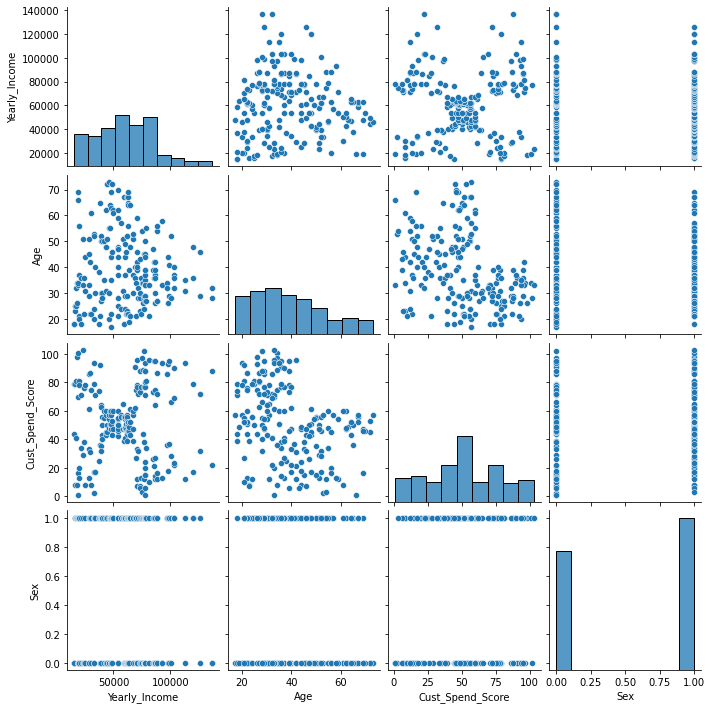

In [9]:
sns.pairplot(data1)
plt.show()

In [10]:
filt=data1[["Cust_Spend_Score","Yearly_Income"]]
filt

,Cust_Spend_Score,Yearly_Income
0,44,15000
1,79,15000
2,8,16000
3,79,16000
4,41,17000
...,...,...
195,79,120000
196,32,126000
197,72,126000
198,22,137000


In [11]:
#sacaling  is mandatoty
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x=sc.fit_transform(filt)
x=pd.DataFrame(x,columns=filt.columns)
x

,Cust_Spend_Score,Yearly_Income
0,-0.284181,-1.738999
1,1.063563,-1.738999
2,-1.670433,-1.700830
3,1.063563,-1.700830
4,-0.399702,-1.662660
...,...,...
195,1.063563,2.268791
196,-0.746265,2.497807
197,0.794014,2.497807
198,-1.131335,2.917671


In [12]:
from sklearn.cluster import KMeans

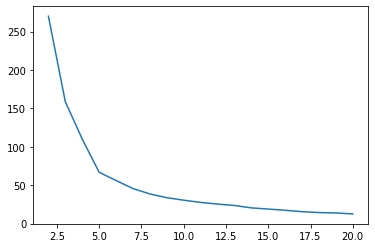

In [13]:
# Elbow method to find optimal cluster
wcss=[]

for i in range(2,21):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)# wcss calculating function
plt.plot(range(2,21),wcss)
#plt.axvline(x=5,color='red')
plt.show()

In [14]:
#silhoutee score
from sklearn.metrics import silhouette_score
for i in range(2,20):
    cluster=KMeans(n_clusters=i)
    predict=cluster.fit_predict(x)
    score=silhouette_score(x,predict)
    print("for {} clusters the silcoutte score is {}".format(i,score))

for 2 clusters the silcoutte score is 0.2931044680017358
for 3 clusters the silcoutte score is 0.46552325533158884
for 4 clusters the silcoutte score is 0.49532835978871026
for 5 clusters the silcoutte score is 0.5520621436353863
for 6 clusters the silcoutte score is 0.5400545310387509
for 7 clusters the silcoutte score is 0.5301955242734531
for 8 clusters the silcoutte score is 0.4443127733410834
for 9 clusters the silcoutte score is 0.44815286222108
for 10 clusters the silcoutte score is 0.44027802918677017
for 11 clusters the silcoutte score is 0.4277239865773235
for 12 clusters the silcoutte score is 0.41340738225732826
for 13 clusters the silcoutte score is 0.4211842564019679
for 14 clusters the silcoutte score is 0.4310911522038854
for 15 clusters the silcoutte score is 0.41551979616945384
for 16 clusters the silcoutte score is 0.423093902243465
for 17 clusters the silcoutte score is 0.40751955416584307
for 18 clusters the silcoutte score is 0.4115454871139012
for 19 clusters the

In [39]:
# Model building
clusters=KMeans(n_clusters=5,init="k-means++")
clusters.fit_predict(x)

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 0,
       4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2], dtype=int32)

In [40]:
clusters.labels_

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 0,
       4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2], dtype=int32)

In [41]:
clusters.cluster_centers_

array([[-0.00693126, -0.22414997],
       [-1.24685589,  1.02054738],
       [ 1.23437568,  0.99158305],
       [ 1.16441429, -1.35366972],
       [-1.12631231, -1.30751869]])

In [42]:
data["cluster"]=clusters.labels_

In [43]:
data

,Cust_Number,Yearly_Income,Age,Cust_Spend_Score,Sex,cluster
0,CUSTID1,15000,18,44,0,4
1,CUSTID2,15000,18,79,0,3
2,CUSTID3,16000,23,8,1,4
3,CUSTID4,16000,25,79,1,3
4,CUSTID5,17000,32,41,1,4
...,...,...,...,...,...,...
195,CUSTID196,120000,36,79,1,2
196,CUSTID197,126000,46,32,1,1
197,CUSTID198,126000,29,72,0,2
198,CUSTID199,137000,32,22,0,1


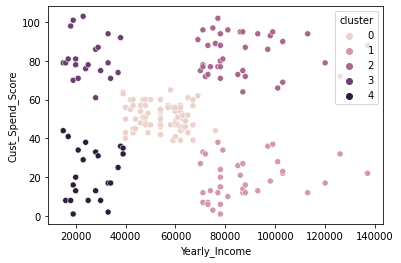

In [44]:
sns.scatterplot(x=data["Yearly_Income"],y=data["Cust_Spend_Score"],hue=data["cluster"])
plt.show()

In [21]:
data["cluster"].value_counts()

4    80
3    39
5    27
0    23
1    21
2    10
Name: cluster, dtype: int64

In [22]:
data[data["cluster"]==4].describe(include="all")

,Cust_Number,Yearly_Income,Age,Cust_Spend_Score,Sex,cluster
count,80,80.00000,80.000000,80.000000,80.0,80.0
unique,80,NaN,NaN,NaN,2.0,NaN
top,CUSTID44,NaN,NaN,NaN,1.0,NaN
freq,1,NaN,NaN,NaN,48.0,NaN
mean,NaN,54687.50000,43.387500,51.200000,NaN,4.0
std,NaN,8839.77454,16.593802,6.404903,NaN,0.0
min,NaN,39000.00000,17.000000,39.000000,NaN,4.0
25%,NaN,47750.00000,28.750000,47.000000,NaN,4.0
50%,NaN,54000.00000,45.000000,51.000000,NaN,4.0
75%,NaN,62000.00000,56.250000,56.000000,NaN,4.0


In [23]:
data[data["cluster"]==0].describe(include="all")

,Cust_Number,Yearly_Income,Age,Cust_Spend_Score,Sex,cluster
count,23,23.000000,23.000000,23.000000,23.0,23.0
unique,23,NaN,NaN,NaN,2.0,NaN
top,CUSTID1,NaN,NaN,NaN,1.0,NaN
freq,1,NaN,NaN,NaN,14.0,NaN
mean,NaN,26304.347826,45.695652,22.130435,NaN,0.0
std,NaN,7893.811055,13.237120,13.222929,NaN,0.0
min,NaN,15000.000000,18.000000,1.000000,NaN,0.0
25%,NaN,19500.000000,36.500000,10.500000,NaN,0.0
50%,NaN,25000.000000,45.000000,20.000000,NaN,0.0
75%,NaN,33000.000000,52.500000,33.500000,NaN,0.0


In [24]:
data[data["cluster"]==1].describe(include="all")

,Cust_Number,Yearly_Income,Age,Cust_Spend_Score,Sex,cluster
count,21,21.000000,21.00000,21.000000,21.0,21.0
unique,21,NaN,NaN,NaN,2.0,NaN
top,CUSTID2,NaN,NaN,NaN,1.0,NaN
freq,1,NaN,NaN,NaN,12.0,NaN
mean,NaN,25095.238095,25.00000,81.619048,NaN,1.0
std,NaN,7133.756107,5.51362,10.901726,NaN,0.0
min,NaN,15000.000000,18.00000,61.000000,NaN,1.0
25%,NaN,19000.000000,21.00000,75.000000,NaN,1.0
50%,NaN,24000.000000,24.00000,79.000000,NaN,1.0
75%,NaN,30000.000000,30.00000,87.000000,NaN,1.0


In [25]:
data[data["cluster"]==2].describe(include="all")

,Cust_Number,Yearly_Income,Age,Cust_Spend_Score,Sex,cluster
count,10,10.000000,10.000000,10.000000,10.0,10.0
unique,10,NaN,NaN,NaN,2.0,NaN
top,CUSTID181,NaN,NaN,NaN,1.0,NaN
freq,1,NaN,NaN,NaN,7.0,NaN
mean,NaN,109700.000000,40.400000,24.700000,NaN,2.0
std,NaN,13768.321127,7.121173,8.340663,NaN,0.0
min,NaN,97000.000000,31.000000,12.000000,NaN,2.0
25%,NaN,99500.000000,34.500000,19.000000,NaN,2.0
50%,NaN,103000.000000,40.500000,22.500000,NaN,2.0
75%,NaN,118250.000000,45.500000,31.000000,NaN,2.0


In [26]:
data[data["cluster"]==3].describe(include="all")

,Cust_Number,Yearly_Income,Age,Cust_Spend_Score,Sex,cluster
count,39,39.000000,39.000000,39.000000,39.0,39.0
unique,39,NaN,NaN,NaN,2.0,NaN
top,CUSTID124,NaN,NaN,NaN,1.0,NaN
freq,1,NaN,NaN,NaN,21.0,NaN
mean,NaN,86538.461538,32.589744,83.435897,NaN,3.0
std,NaN,16312.484973,4.511494,10.176844,NaN,0.0
min,NaN,69000.000000,26.000000,64.000000,NaN,3.0
25%,NaN,75500.000000,28.500000,75.000000,NaN,3.0
50%,NaN,79000.000000,33.000000,86.000000,NaN,3.0
75%,NaN,95000.000000,36.000000,93.500000,NaN,3.0


# Hierarchical Clustering


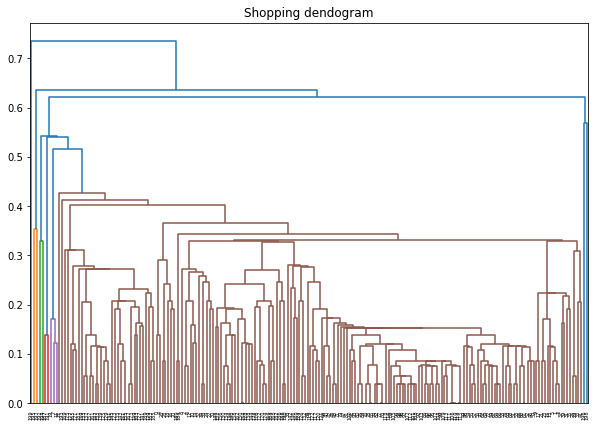

In [46]:
import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10,7))
plt.title("Shopping dendogram")

dend=shc.dendrogram(shc.linkage(x,method="single"))
plt.show()

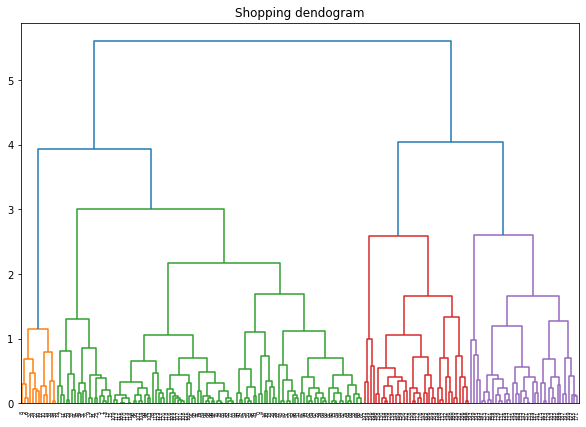

In [47]:
import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10,7))
plt.title("Shopping dendogram")

dend=shc.dendrogram(shc.linkage(x,method="complete"))
plt.show()

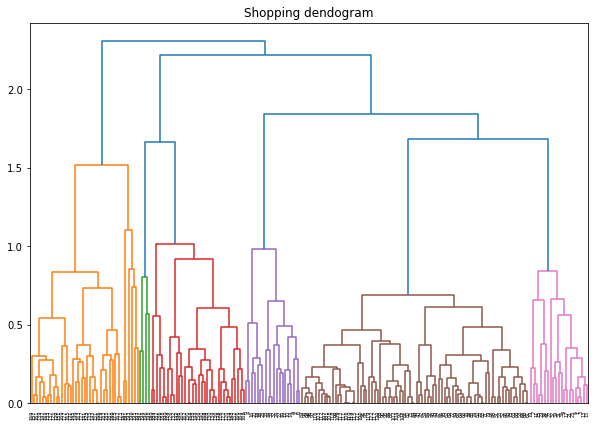

In [48]:
import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10,7))
plt.title("Shopping dendogram")

dend=shc.dendrogram(shc.linkage(x,method="average"))
plt.show()

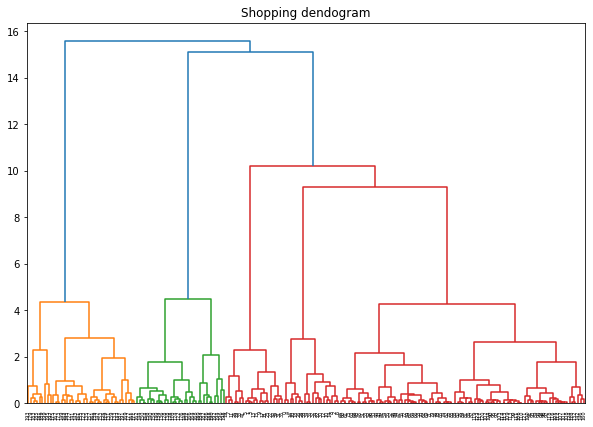

In [50]:
import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10,7))
plt.title("Shopping dendogram")

dend=shc.dendrogram(shc.linkage(x,method="ward"))
plt.show()

In [65]:
from sklearn.metrics import silhouette_score,silhouette_samples
from sklearn.cluster import AgglomerativeClustering
n_clusters = [2, 3, 4, 5, 6,7,8,9]

for K in n_clusters:
    clusterh = AgglomerativeClustering (n_clusters= K, linkage="ward")
    predicth = clusterh.fit_predict(x)
    score = silhouette_score(x, predicth)
    print ("For {} clusters the silhouette score is {})".format(K, score))

For 2 clusters the silhouette score is 0.3812653054399621)
For 3 clusters the silhouette score is 0.4569777691896557)
For 4 clusters the silhouette score is 0.48803461290989575)
For 5 clusters the silhouette score is 0.5446701394258364)
For 6 clusters the silhouette score is 0.5311997416041335)
For 7 clusters the silhouette score is 0.5122262633075478)
For 8 clusters the silhouette score is 0.4326411984841292)
For 9 clusters the silhouette score is 0.4273872857139287)


In [60]:
from sklearn.cluster import AgglomerativeClustering
aggmodel=AgglomerativeClustering(n_clusters=5,linkage="ward")
aggmodel.fit(x)

AgglomerativeClustering(n_clusters=5)

In [61]:
data["Cluster_h"]=aggmodel.labels_
data.head()

,Cust_Number,Yearly_Income,Age,Cust_Spend_Score,Sex,cluster,Cluster_h
0,CUSTID1,15000,18,44,0,4,4
1,CUSTID2,15000,18,79,0,3,3
2,CUSTID3,16000,23,8,1,4,4
3,CUSTID4,16000,25,79,1,3,3
4,CUSTID5,17000,32,41,1,4,4


In [62]:
data["Cluster_h"].value_counts()

2    88
1    39
0    32
3    21
4    20
Name: Cluster_h, dtype: int64

In [63]:
data["cluster"].value_counts()

0    80
2    39
1    37
4    23
3    21
Name: cluster, dtype: int64

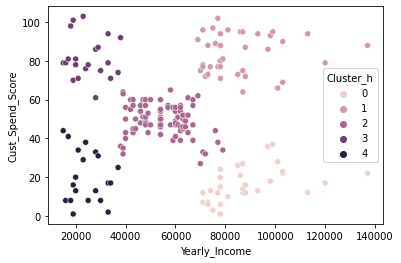

In [66]:
sns.scatterplot(x=data["Yearly_Income"],y=data["Cust_Spend_Score"],hue=data["Cluster_h"])
plt.show()

# DBSCAN

In [28]:
datas=pd.read_csv("db2.csv")
datas

,Unnamed: 0,F1,F2
0,0,1.047751,0.071995
1,1,0.020275,0.161049
2,2,-0.671793,0.750891
3,3,-0.774415,0.649314
4,4,-0.379833,0.952658
...,...,...,...
495,495,1.974937,0.188991
496,496,0.279537,-0.201197
497,497,1.918825,0.131525
498,498,0.068505,0.312760


In [29]:
datas.drop("Unnamed: 0",axis=1,inplace=True)


In [30]:
datas

,F1,F2
0,1.047751,0.071995
1,0.020275,0.161049
2,-0.671793,0.750891
3,-0.774415,0.649314
4,-0.379833,0.952658
...,...,...
495,1.974937,0.188991
496,0.279537,-0.201197
497,1.918825,0.131525
498,0.068505,0.312760


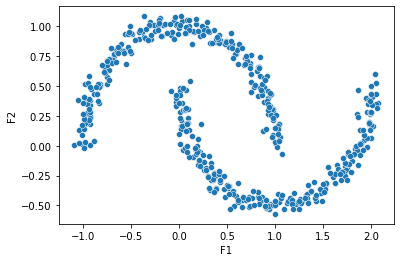

In [31]:
sns.scatterplot(x=datas["F1"],y=datas["F2"])
plt.show()

In [32]:
kmeans1=KMeans(n_clusters=2)
clu=kmeans1.fit_predict(datas)

In [33]:
clu

array([0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,

<AxesSubplot: xlabel='F1', ylabel='F2'>

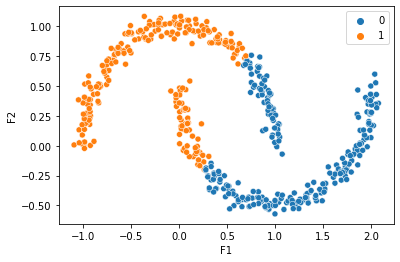

In [34]:
sns.scatterplot(x=datas["F1"],y=datas["F2"],hue=clu)

In [35]:
#DBSCAN
from sklearn.cluster import DBSCAN
db1=DBSCAN(eps=0.15,min_samples=5)
dbclust=db1.fit_predict(datas)

<AxesSubplot: xlabel='F1', ylabel='F2'>

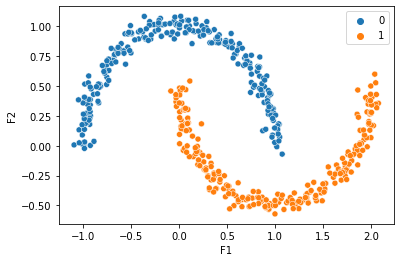

In [36]:
sns.scatterplot(x=datas["F1"],y=datas["F2"],hue=dbclust)

In [37]:
dbclust

array([0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0,